## CNN Classifier for MNIST Handwritten Digit Dataset

This project implements a Convolutional Neural Network (CNN) to classify handwritten digits using the MNIST dataset.

### 📚 Dataset: MNIST
- **Source**: [Yann LeCun’s MNIST Database](http://yann.lecun.com/exdb/mnist/)
- **Description**: A benchmark dataset in computer vision and machine learning.
- **Image Type**: Grayscale, 28x28 pixels
- **Total Images**: 70,000
  - **Training**: 60,000 images
  - **Testing**: 10,000 images
- **Classes**: 10 (Digits 0 through 9)

### 🧪 Goal
Train a deep learning model to recognize handwritten digits with high accuracy. This task is widely used to benchmark image classification algorithms.

### Technologies
- Python
- TensorFlow / Keras
- CNN architecture
- Matplotlib for visualization



In [1]:
# Step 1: Import Required Libraries
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
import matplotlib.pyplot as plt

In [2]:
#  Step 2: Load the MNIST Dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 16s 1us/step


In [3]:
# Step 3: Preprocess the Data
# Reshape to add channel dimension (grayscale images)
X_train = X_train.reshape(-1, 28, 28, 1).astype('float32') / 255.0
X_test = X_test.reshape(-1, 28, 28, 1).astype('float32') / 255.0

In [4]:
# One-hot encode the labels
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

In [5]:
# Step 4: Build the CNN Model
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D((2, 2)),
    
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')  # 10 output classes
])


C:\Users\njavanba\.conda\envs\cleanml\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [6]:
# Step 5: Compile the Model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


In [7]:
# Step 6: Train the Model
history = model.fit(X_train, y_train, epochs=5, batch_size=64, validation_split=0.1)

Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - accuracy: 0.8319 - loss: 0.5294 - val_accuracy: 0.9855 - val_loss: 0.0514
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.9728 - loss: 0.0952 - val_accuracy: 0.9877 - val_loss: 0.0442
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.9796 - loss: 0.0673 - val_accuracy: 0.9885 - val_loss: 0.0413
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - accuracy: 0.9837 - loss: 0.0532 - val_accuracy: 0.9905 - val_loss: 0.0330
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.9865 - loss: 0.0422 - val_accuracy: 0.9910 - val_loss: 0.0343


In [8]:
# Step 7: Evaluate the Model
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"\n🧪 Test Accuracy: {test_acc:.4f}")


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9888 - loss: 0.0362

🧪 Test Accuracy: 0.9913


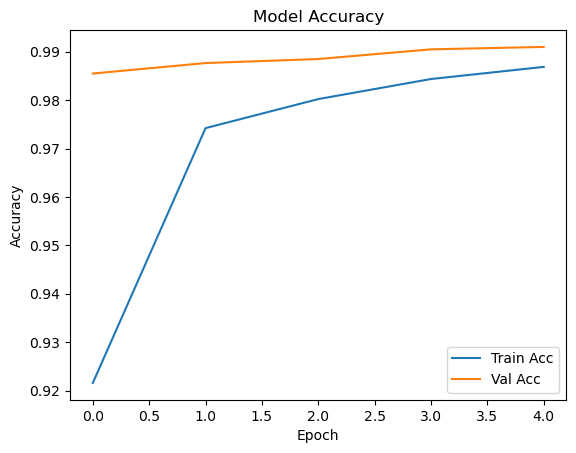

In [9]:
# Step 8: Plot Training History
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()